Loading MF snapshot: /home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt
W_dN shape (d,N): (35, 1536)


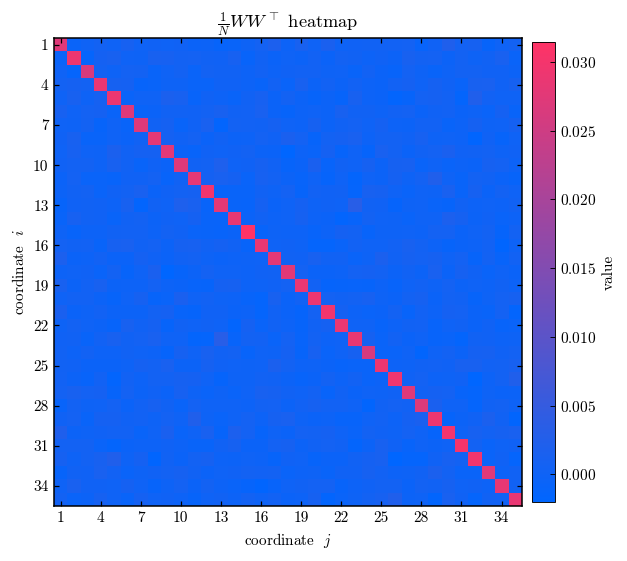

/tmp/ipykernel_1856366/3803342337.py:313: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


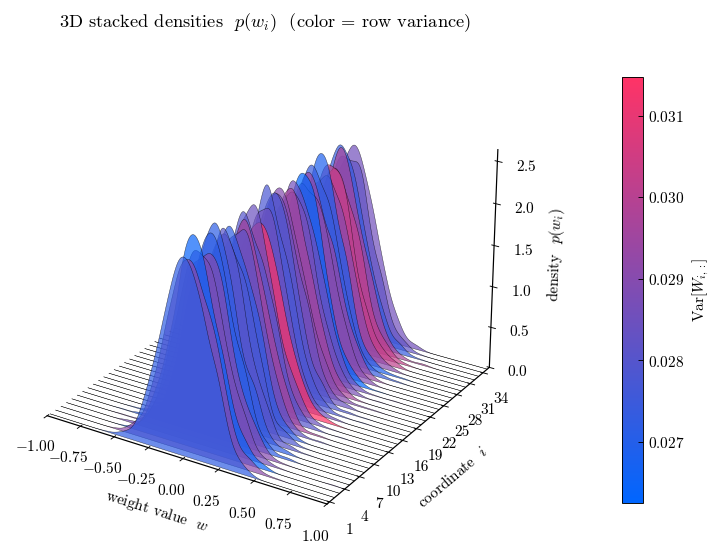

In [2]:
# === MF snapshot: WW^T heatmap + 3D ridgeline for p(w_i) (boxed look, custom hex gradient, vmin/vmax) ===
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------
def import_slim_plotters():
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]
    # 1) Direct file import path
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            import slim_plotters as sp  # noqa
            return sp
    # 2) Package-style imports
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass
    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE
apply(theme="light", serif=True)  # or theme="dark"

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------
def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")

def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# IO helpers for MF snapshots
# -----------------------------------------------------------------------------
def find_latest_snapshot(model_dir, suffix="__final_particles.pt"):
    files = glob.glob(os.path.join(model_dir, f"*{suffix}"))
    if not files:
        raise FileNotFoundError(f"No *{suffix} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_mf_snapshot_to_dN(path, experiment="all", stride=1, map_location="cpu"):
    """
    Load MF snapshot .pt and return:
      W_dN: (d, N_total), a_N: (N_total,), meta: dict
    - experiment: "all" to concat all E; or an int e to pick a single experiment.
    - stride: subsample along B to thin.
    """
    pkg = torch.load(path, map_location=map_location)
    W = pkg["params"]["W"]    # (E,B,d)
    a = pkg["params"]["a"]    # (E,B,1)
    meta = pkg["meta"]

    if experiment == "all":
        W2 = W[:, ::stride, :]              # (E, B', d)
        a2 = a[:, ::stride, :]              # (E, B', 1)
        E, Bp, d = W2.shape
        Wflat = W2.reshape(E*Bp, d)         # (E*B', d)
        aflat = a2.reshape(E*Bp)            # (E*B',)
    else:
        e = int(experiment)
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)

    W_dN = Wflat.T.contiguous().float().cpu()   # (d,N)
    a_N  = aflat.contiguous().float().cpu()     # (N,)
    return W_dN, a_N, meta

# -----------------------------------------------------------------------------
# Minimal 1D Gaussian KDE (no SciPy dependency)
# -----------------------------------------------------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# -----------------------------------------------------------------------------
# Palette → colormap (customizable with hex stops)
# -----------------------------------------------------------------------------
def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: e.g. ['#0066ff', '#ff3366'] or ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

# -----------------------------------------------------------------------------
# Styled WW^T heatmap (custom cmap + vmin/vmax + boxed look)
# -----------------------------------------------------------------------------
def plot_WWT_heatmap(
    W_dN,
    *,
    normalize_by_N=True,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    width=5.8,
    aspect=1.0,
    title=r"$WW^\top$ heatmap"
):
    """
    W_dN: (d,N)  -> G = W W^T (optionally / N)
    """
    W_np = W_dN.detach().cpu().numpy()
    d, N = W_np.shape
    G = W_np @ W_np.T
    if normalize_by_N and N > 0:
        G = G / float(N)

    cm = linear_cmap_from_hex(cmap_stops_hex, name="wwtmap")
    vmin_use = np.min(G) if vmin is None else float(vmin)
    vmax_use = np.max(G) if vmax is None else float(vmax)
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12

    fig, ax = plt.subplots(figsize=(width, width / aspect))
    im = ax.imshow(G, cmap=cm, vmin=vmin_use, vmax=vmax_use, origin="upper", interpolation="nearest")
    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label(r"value")

    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_title(title)

    # Boxed, clean look
    style_axes_box(ax)

    # Integer ticks if d is small
    if d <= 40:
        ticks = np.arange(0, d, max(1, d // 10))
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(ticks + 1)
        ax.set_yticklabels(ticks + 1)

    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Styled 3D ridgeline for p(w_i) (custom cmap stops + vmin/vmax for variance + boxed look)
# -----------------------------------------------------------------------------
def plot_coordinate_kdes_3d(
    W_dN,
    grid_points=401,
    weight_range=None,
    bandwidth=None,
    normalize_rows=False,   # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,           # >1 to thin if d is large
    max_rows=None,
    cmap_stops_hex=None,    # list of hex colors for gradient (start/stop or start/mid/stop)
    var_vmin=None,          # min variance mapped to colormap (if None, computed)
    var_vmax=None           # max variance mapped to colormap (if None, computed)
):
    W_np = W_dN.detach().cpu().numpy()
    d, N = W_np.shape

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # symmetric range if not provided
    if weight_range is None:
        abs_vals = np.abs(W_np).ravel()
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    dens, variances = [], []
    for i in rows:
        di = gaussian_kde_1d(W_np[i, :], grid, bandwidth=bandwidth)
        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m
        dens.append(di)
        variances.append(np.var(W_np[i, :], ddof=1))
    dens = np.asarray(dens)
    variances = np.asarray(variances)

    # color by variance using your custom palette
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use): vmin_use = vmin_auto
    if not np.isfinite(vmax_use): vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di, v in zip(dens, variances):
        poly = list(zip(grid, di)) + [(grid[-1], 0.0), (grid[0], 0.0)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )

    fig = plt.figure(figsize=(10.0, 6.0))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')
    ys = np.arange(len(rows)) * y_step
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens)) if dens.size else 1.0
    ax.set_zlim(0.0, zmax * 1.05)

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(r"density  $p(w_i)$")
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$")

    # Clean boxed style
    style_3d_axes_box(ax)

    ax.set_title("3D stacked densities  $p(w_i)$  (color = row variance)")
    plt.tight_layout()
    plt.show()
    return fig

# -----------------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------------
# Option A: direct snapshot file (init or final)
SNAPSHOT_FILE = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt"

# Option B: newest *__final_particles.pt in a directory
# SNAPSHOT_DIR = "/home/goring/mean_field_langevin/MCMC_composite/some_results_dir"
# SNAPSHOT_FILE = find_latest_snapshot(SNAPSHOT_DIR, suffix="__final_particles.pt")

print("Loading MF snapshot:", SNAPSHOT_FILE)
W_dN, a_N, meta = load_mf_snapshot_to_dN(SNAPSHOT_FILE, experiment="all", stride=1)
print("W_dN shape (d,N):", tuple(W_dN.shape))

# ---- Customize your colors & ranges here ----
CMAP_STOPS = ["#0066ff", "#ff3366"]   # or ["#0066ff", "#8a3ffc", "#ff3366"]
HEAT_VMIN = None                      # color scale for heatmap (auto if None)
HEAT_VMAX = None
VAR_VMIN = None                       # row-variance → color mapping (auto if None)
VAR_VMAX = None

# 1) WW^T heatmap (normalized by N)
_ = plot_WWT_heatmap(
    W_dN,
    normalize_by_N=True,
    cmap_stops_hex=CMAP_STOPS,
    vmin=HEAT_VMIN,
    vmax=HEAT_VMAX,
    width=5.8,
    aspect=1.0,
    title=r"$\frac{1}{N}WW^\top$ heatmap"
)

# 2) 3D ridgeline for p(w_i)
_ = plot_coordinate_kdes_3d(
    W_dN,
    grid_points=4001,
    weight_range=(-1, 1),     # set fixed range (or None for auto)
    bandwidth=None,           # Scott's rule per row
    normalize_rows=False,     # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.7,
    elev=26,
    azim=-58,
    row_stride=1,             # use 2/3/... to thin if d is large
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX
)


In [ ]:
# === MF snapshot: p(~m) overlay (two models) in slim style ===
import os, sys, glob, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----------------------------------------------------------------------------- #
# robust import of your slim_plotters.py
# ----------------------------------------------------------------------------- #
def import_slim_plotters():
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            import slim_plotters as sp
            return sp
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass
    raise ModuleNotFoundError("slim_plotters.py not found — update candidate paths above.")

sp = import_slim_plotters()
apply, color, COLORS = sp.apply, sp.color, sp.COLORS
apply(theme="light", serif=True)  # or theme="dark"

# ----------------------------------------------------------------------------- #
# IO helpers for MF snapshots
# ----------------------------------------------------------------------------- #
def find_latest_snapshot(model_dir, suffix="__final_particles.pt"):
    files = glob.glob(os.path.join(model_dir, f"*{suffix}"))
    if not files:
        raise FileNotFoundError(f"No *{suffix} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_mf_snapshot_to_dN(path, experiment="all", stride=1, map_location="cpu"):
    """
    Load MF snapshot .pt saved by the trainer and return:
      W_dN: (d, N_total), a_N: (N_total,), act: str, scale_f: float, meta: dict
    - experiment: "all" to concatenate all E experiments; or an int e to pick one.
    - stride: subsample along particle axis B to thin.
    """
    pkg = torch.load(path, map_location=map_location)
    W = pkg["params"]["W"]    # (E,B,d)
    a = pkg["params"]["a"]    # (E,B,1)
    meta = pkg["meta"]
    act = meta["model"]["act"]
    scale_f = float(meta["scale_f"])

    if experiment == "all":
        W2 = W[:, ::stride, :]              # (E, B', d)
        a2 = a[:, ::stride, :]              # (E, B', 1)
        E, Bp, d = W2.shape
        Wflat = W2.reshape(E*Bp, d)         # (E*B', d)
        aflat = a2.reshape(E*Bp)            # (E*B',)
    else:
        e = int(experiment)
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)

    # convert to (d,N) and (N,)
    W_dN = Wflat.T.contiguous().float().cpu()
    a_N  = aflat.contiguous().float().cpu()
    return W_dN, a_N, act, scale_f, meta

# ----------------------------------------------------------------------------- #
# Monte Carlo estimator for J_S(w) respecting MF activation
# W_dN: (d,N), returns JS: (N,)
# ----------------------------------------------------------------------------- #
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0  # (b,d)
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------------------------------------------------------- #
# Simple Gaussian KDE (no SciPy), identical to your previous
# ----------------------------------------------------------------------------- #
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1)
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# ----------------------------------------------------------------------------- #
# Two-model overlay (unchanged visual style; multiplies inside)
# ----------------------------------------------------------------------------- #
def plot_mtilde_distribution_two_models(
    a1, JS1, a2, JS2, *,
    grid_points=801,
    weight_range=None,         # (lo, hi) or None (auto from both)
    color_hex1="#8710FF",      # color for model 1
    color_hex2="#01B5EB",      # color for model 2
    alpha1=1.0, alpha2=0.55,   # opacity only
    linewidth=2.0,
    fill_alpha_scale=0.25,     # fill alpha = alpha*fill_alpha_scale
    density_floor=1e-12,
    label1="run 1", label2="run 2",
    width=4.6, aspect=1.35,
    x_range=None, y_range=None
):
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    m1 = a1.detach().cpu().numpy().ravel() * JS1.detach().cpu().numpy().ravel()
    m2 = a2.detach().cpu().numpy().ravel() * JS2.detach().cpu().numpy().ravel()

    if weight_range is None:
        all_abs = np.abs(np.concatenate([m1, m2])) if (m1.size and m2.size) else np.abs(m1 if m1.size else m2)
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    p1 = np.clip(gaussian_kde_1d(m1, grid), density_floor, None)
    p2 = np.clip(gaussian_kde_1d(m2, grid), density_floor, None)

    fig, ax = plt.subplots(figsize=(width, width / aspect))
    # curves + fill
    ax.semilogy(grid, p1, color=color_hex1, lw=linewidth, alpha=alpha1, label=label1)
    ax.fill_between(grid, p1, density_floor, color=color_hex1, alpha=alpha1*fill_alpha_scale, linewidth=0)

    ax.semilogy(grid, p2, color=color_hex2, lw=linewidth, alpha=alpha2, label=label2)
    ax.fill_between(grid, p2, density_floor, color=color_hex2, alpha=alpha2*fill_alpha_scale, linewidth=0)

    # labels & legend
    ax.set_title("")
    ax.set_xlabel(r"value of $\tilde m$")
    ax.set_ylabel("")
    ax.legend(frameon=False, loc="upper right")

    # ---- MINOR TICKS: only bottom & left ----
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    return fig

# ----------------------------------------------------------------------------- #
# === Usage with MF snapshots ===
# ----------------------------------------------------------------------------- #
# Option A: point directly to two snapshot files
SNAP_A = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt"
SNAP_B = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt"

# Option B: or find the latest final snapshot under two result dirs
# SNAP_A = find_latest_snapshot("/home/goring/mean_field_langevin/MCMC_composite/results_runA")
# SNAP_B = find_latest_snapshot("/home/goring/mean_field_langevin/MCMC_composite/results_runB")

print("Loading MF snapshot A:", SNAP_A)
WA_dN, aA, actA, scaleA, metaA = load_mf_snapshot_to_dN(SNAP_A, experiment="all", stride=1)
print("Loading MF snapshot B:", SNAP_B)
WB_dN, aB, actB, scaleB, metaB = load_mf_snapshot_to_dN(SNAP_B, experiment="all", stride=1)

# Estimate J_S(w) for both (respect their activations)
S = (0,1,2,3)
device = "cuda" if torch.cuda.is_available() else "cpu"
JS_A = estimate_JS_for_all_neurons_MF(WA_dN, act=actA, S=S,
                                      num_samples=100_000, batch_size=20_000,
                                      device=device, seed=123)
JS_B = estimate_JS_for_all_neurons_MF(WB_dN, act=actB, S=S,
                                      num_samples=100_000, batch_size=20_000,
                                      device=device, seed=124)

# IMPORTANT for MF: multiply a by scale_f so m~ = (scale_f * a) * J_S(w)
aA_scaled = aA * float(scaleA)
aB_scaled = aB * float(scaleB)

_ = plot_mtilde_distribution_two_models(
    aA_scaled, JS_A, aB_scaled, JS_B,
    grid_points=1801,
    weight_range=(-15.5, 15.5),   # or None
    color_hex1="#8710FF",         # purple for run 1
    color_hex2="#01B5EB",         # blue for run 2
    alpha1=1.0, alpha2=0.55,
    linewidth=2.0,
    fill_alpha_scale=0.25,
    density_floor=1e-6,
    label1="run 1", label2="run 2",
    width=4.6, aspect=1.35,
    x_range=(-2, 10),             # or None
    y_range=None
)


Loading MF snapshot A: /home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt
Loading MF snapshot B: /home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__init_particles.pt
